In [30]:
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN


In [31]:
df = pd.read_csv("data_avec_material_type.csv", low_memory=False)
# Ne pas tout supprimer ici : la cellule "Normalisation" s'occupe du nettoyage ciblé

In [32]:
# --- Normalisation des données (DataSF / autres sources) : une seule cellule pour tout adapter ---
import re

# 1) Renommage des colonnes (DataSF → noms attendus par le reste du notebook)
COLUMN_MAP = {
    'neighborhoods_analysis_boundaries': 'Neighborhoods - Analysis Boundaries',
}
df = df.rename(columns={k: v for k, v in COLUMN_MAP.items() if k in df.columns})

# 2) Latitude / Longitude : depuis Location (POINT ou (lat,long)) ou déjà présentes
if 'Latitude' not in df.columns or 'Longitude' not in df.columns:
    if 'Location' in df.columns:
        def parse_location(loc):
            if pd.isna(loc) or str(loc).strip() == '':
                return float('nan'), float('nan')
            s = str(loc).strip()
            if 'POINT' in s.upper():
                m = re.search(r'[-+]?\d+\.?\d*\s+[-+]?\d+\.?\d*', s)
                if m:
                    parts = m.group().split()
                    lon, lat = float(parts[0]), float(parts[1])
                    return lat, lon
            else:
                s = s.strip(' ()')
                parts = s.replace(',', ' ').split()
                if len(parts) >= 2:
                    return float(parts[0]), float(parts[1])
            return float('nan'), float('nan')
        df[['Latitude', 'Longitude']] = df['Location'].apply(lambda x: pd.Series(parse_location(x)))
        df.drop(columns=['Location'], inplace=True, errors='ignore')

# 3) Coercion des coûts en numériques (DataSF peut les avoir en string)
for col in ['Estimated Cost', 'Revised Cost']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
# Colonnes optionnelles manquantes (DataSF n'a pas Materials/Labor Cost ni Material_Type)
if 'Materials Cost' not in df.columns:
    df['Materials Cost'] = (df['Estimated Cost'] * 0.5) if 'Estimated Cost' in df.columns else 0
if 'Labor Cost' not in df.columns:
    df['Labor Cost'] = (df['Estimated Cost'] * 0.5) if 'Estimated Cost' in df.columns else 0
if 'Material_Type' not in df.columns:
    df['Material_Type'] = 'Other'

# 4) Suppression des lignes sans valeurs essentielles (évite de tout supprimer avec dropna())
key_cols = [c for c in ['Estimated Cost', 'Revised Cost', 'Latitude', 'Longitude', 'Neighborhoods - Analysis Boundaries'] if c in df.columns]
if key_cols:
    df = df.dropna(subset=key_cols)

In [34]:
df.head()

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Number Suffix,Street Name,Street Suffix,...,Record ID,Primary Address Flag,point_source,data_as_of,data_loaded_at,Latitude,Longitude,Materials Cost,Labor Cost,Material_Type
0,202602035165,8,otc alterations permit,2026/02/03 10:39:43 PM,1810,003,1427,NaN,43rd,Av,...,1742321115242,Y,eas_address_point,2026/02/04 01:05:05 AM,2026/02/04 04:44:02 AM,37.760066,-122.503008,6000.0,6000.0,Other
2,202602035164,8,otc alterations permit,2026/02/03 04:53:48 PM,2114,038,1922,NaN,21st,Av,...,1742320126330,Y,eas_address_point,2026/02/04 01:05:05 AM,2026/02/04 04:44:02 AM,37.751812,-122.478122,7000.0,7000.0,Other
4,202602035162,8,otc alterations permit,2026/02/03 04:30:17 PM,5381,014,56,NaN,Santa Fe,Av,...,1742318181014,Y,eas_address_point,2026/02/04 01:05:05 AM,2026/02/04 04:44:02 AM,37.733932,-122.400902,7000.0,7000.0,Other
5,S20260203456,9,NaN,2026/02/03 03:46:29 PM,1041,028,175,NaN,Mayfair,Dr,...,174231487996,Y,eas_address_point,2026/02/04 01:05:05 AM,2026/02/04 04:44:02 AM,37.785566,-122.453453,20231.0,20231.0,Other
7,202602035137,8,otc alterations permit,2026/02/03 01:56:28 PM,2623,180,4150,NaN,17th,St,...,1742286492869,Y,eas_address_point,2026/02/04 01:05:05 AM,2026/02/04 04:44:02 AM,37.762434,-122.438456,15000.0,15000.0,Other


In [35]:
# --- Nettoyage des colonnes inutiles ---
df.drop(columns=[
    'Permit Number', 'Description',
    'Existing Construction Type Description',
    'Proposed Construction Type Description'
], errors='ignore', inplace=True)


In [29]:
# --- Coordonnées et nettoyage déjà faits dans la cellule "Normalisation" ci-dessus ---
# Rien à faire ici si vous avez exécuté la cellule de normalisation.

KeyError: 'Location'

In [36]:
# --- Encodage des colonnes catégorielles ---
df['Permit Type Definition'] = LabelEncoder().fit_transform(df['Permit Type Definition'])
df['Neighborhood'] = LabelEncoder().fit_transform(df['Neighborhoods - Analysis Boundaries'])

# --- Suppression des outliers sur les colonnes numériques clés ---
cols_outliers = ['Estimated Cost', 'Revised Cost', 'Materials Cost', 'Labor Cost']
for col in cols_outliers:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [37]:
# --- Création des variables log pour coûts (pour visu et modèle) ---
df['Estimated Cost_log'] = np.log1p(df['Estimated Cost'])
df['Revised Cost_log'] = np.log1p(df['Revised Cost'])

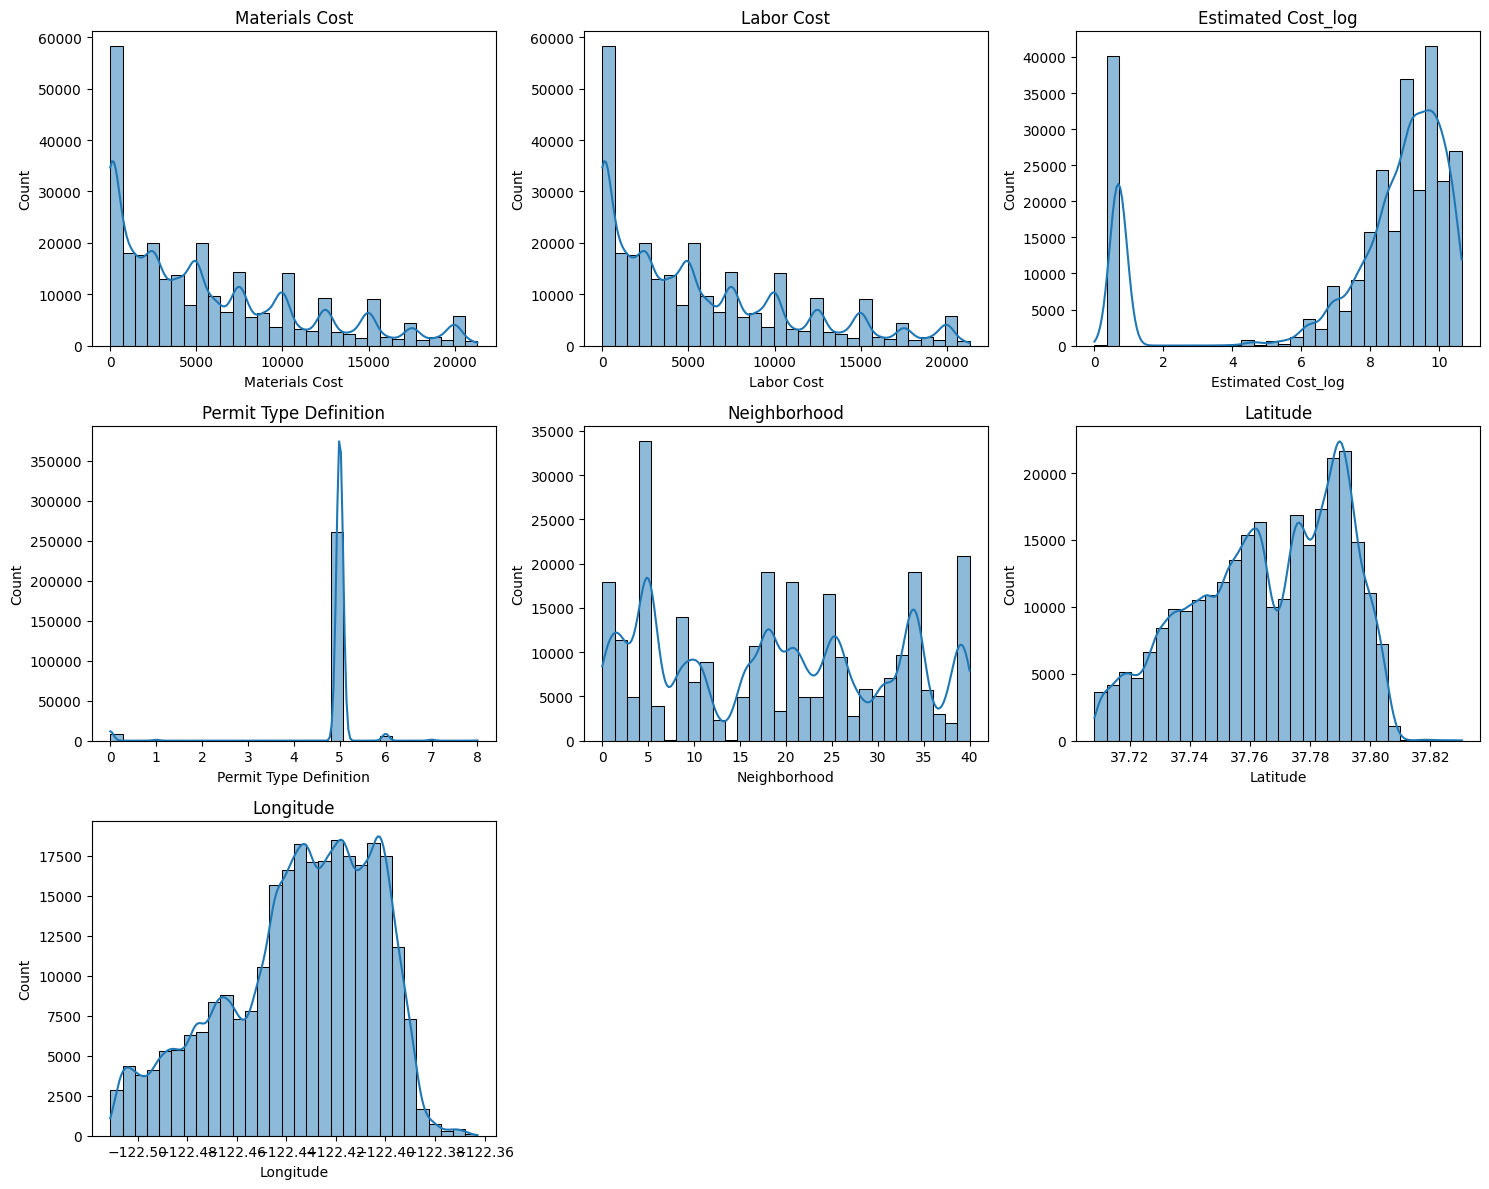

,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Number Suffix,Street Name,Street Suffix,Unit,...,data_as_of,data_loaded_at,Latitude,Longitude,Materials Cost,Labor Cost,Material_Type,Neighborhood,Estimated Cost_log,Revised Cost_log
0,8,5,2026/02/03 10:39:43 PM,1810,003,1427,NaN,43rd,Av,NaN,...,2026/02/04 01:05:05 AM,2026/02/04 04:44:02 AM,37.760066,-122.503008,6000.0,6000.0,Other,34,9.392745,9.392745
1,8,5,2026/02/03 04:53:48 PM,2114,038,1922,NaN,21st,Av,NaN,...,2026/02/04 01:05:05 AM,2026/02/04 04:44:02 AM,37.751812,-122.478122,7000.0,7000.0,Other,34,9.546884,9.546884
2,8,5,2026/02/03 04:30:17 PM,5381,014,56,NaN,Santa Fe,Av,36.0,...,2026/02/04 01:05:05 AM,2026/02/04 04:44:02 AM,37.733932,-122.400902,7000.0,7000.0,Other,0,9.546884,9.546884
3,9,8,2026/02/03 03:46:29 PM,1041,028,175,NaN,Mayfair,Dr,NaN,...,2026/02/04 01:05:05 AM,2026/02/04 04:44:02 AM,37.785566,-122.453453,20231.0,20231.0,Other,30,10.608143,10.608143
4,8,5,2026/02/03 01:56:28 PM,2623,180,4150,NaN,17th,St,13.0,...,2026/02/04 01:05:05 AM,2026/02/04 04:44:02 AM,37.762434,-122.438456,15000.0,15000.0,Other,2,10.308986,10.308986


In [ ]:
# --- Visualisation des distributions (histogrammes) ---
plt.figure(figsize=(15, 12))
numerical_cols = [
    'Materials Cost', 'Labor Cost', 'Estimated Cost_log',
    'Permit Type Definition', 'Neighborhood', 'Latitude', 'Longitude'
]
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
os.makedirs("assets", exist_ok=True)
plt.savefig("assets/01_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Aperçu des données nettoyées
df.reset_index(drop=True, inplace=True)
df.head()


In [39]:


scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numerical_cols])

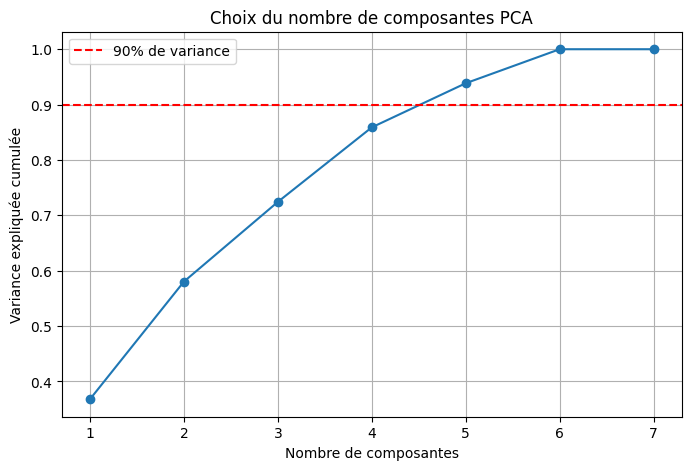

In [ ]:
# PCA sans limitation de composantes
pca = PCA()
pca.fit(X_scaled)

# Visualiser la variance expliquée
explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulée')
plt.title('Choix du nombre de composantes PCA')
plt.grid(True)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% de variance')
plt.legend()
plt.show()


In [42]:
# Cible
y = df['Revised Cost_log']

# PCA avec 5 composantes (déjà justifié par la courbe)
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

# Split des données
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Entraînement du modèle
model = XGBRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Prédiction
y_pred = model.predict(X_test)

# Évaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"✅ MSE : {mse:.4f}")
print(f"✅ R² : {r2:.4f}")

✅ MSE : 3.1616
✅ R² : 0.7103


C:\Users\jasse\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


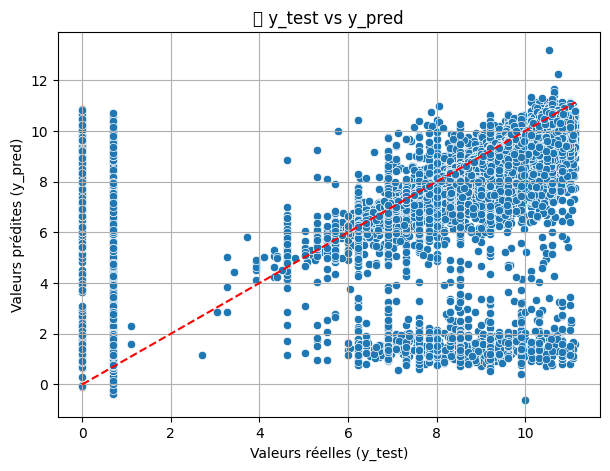

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Valeurs réelles (y_test)")
plt.ylabel("Valeurs prédites (y_pred)")
plt.title("📊 y_test vs y_pred")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.grid(True)
plt.show()


In [44]:
joblib.dump(model, 'xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca.pkl')

print("✅ Model, Scaler, and PCA saved.")

✅ Model, Scaler, and PCA saved.


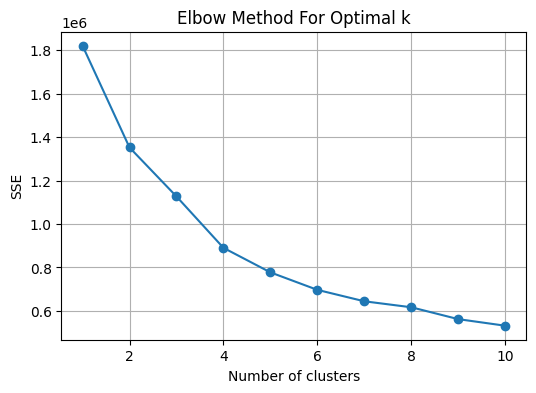

In [ ]:
#unsupervised
# Elbow method
sse = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K, sse, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.grid(True)
plt.show()

In [48]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Add cluster labels to the DataFrame
df['Cluster'] = clusters

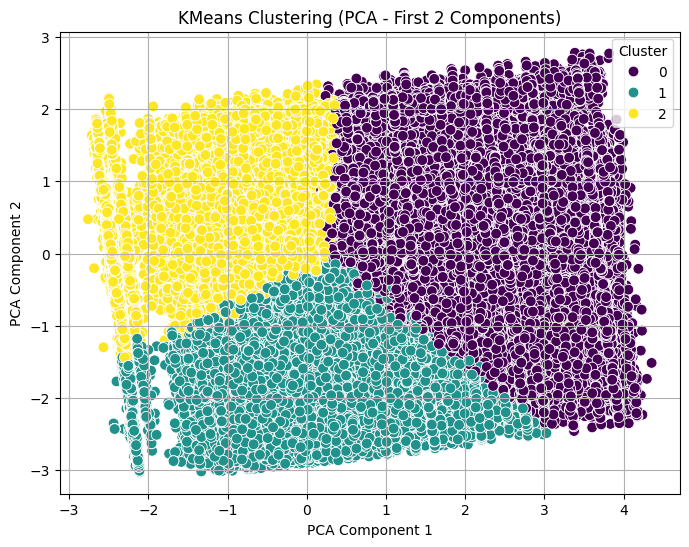

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', s=60)
plt.title("KMeans Clustering (PCA - First 2 Components)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


In [55]:
from sklearn.metrics import silhouette_score

# sample_size évite un calcul O(n²) sur ~277k points (sinon KeyboardInterrupt / blocage)
sil_score = silhouette_score(X_pca, clusters, sample_size=10000, random_state=42)
print(f"Silhouette Score: {sil_score:.3f}")


Silhouette Score: 0.251


In [57]:
# Optionnel : monter Google Drive uniquement en Colab (ignoré en local)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    pass  # Exécution locale (Cursor / VS Code) : pas de Colab